<a href="https://www.kaggle.com/code/shamanthakreddymallu/s6e6-dcn?scriptVersionId=328057835" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Imports & Load

In [1]:
# PATHS
TRAIN_PATH    = '/kaggle/input/competitions/playground-series-s6e6/train.csv'
TEST_PATH     = '/kaggle/input/competitions/playground-series-s6e6/test.csv'
ORIGINAL_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv'

In [2]:
import numpy as np
import math, random, os, gc, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             classification_report)
from sklearn.calibration import calibration_curve
from itertools import product

import warnings
warnings.filterwarnings('ignore')

train    = pd.read_csv(TRAIN_PATH)
test     = pd.read_csv(TEST_PATH)
original = pd.read_csv(ORIGINAL_PATH)

# Standardise original
original = original.rename(columns={'class': 'class'})
original['class'] = original['class'].str.upper().str.strip()

CLASS_COLORS = {'GALAXY': '#4C72B0', 'QSO': '#DD8452', 'STAR': '#55A868'}
CLASS_ORDER  = ['GALAXY', 'QSO', 'STAR']

print('Loaded.')
print(f'Train: {train.shape} | Test: {test.shape} | Original: {original.shape}')

Loaded.
Train: (577347, 12) | Test: (247435, 11) | Original: (100000, 18)


# Clean Original Dataset

In [3]:
SENTINEL = -9999
SENTINEL_COLS = ['u', 'g', 'z']  # confirmed from EDA (std >> normal range)

# How many rows are affected?
for col in SENTINEL_COLS:
    n = (original[col] < -100).sum()
    print(f'Original {col}: {n:,} sentinel rows ({n/len(original)*100:.1f}%)')

# Remove rows where ANY sentinel is present
mask_clean = ~((original['u'] < -100) | (original['g'] < -100) | (original['z'] < -100))
original_clean = original[mask_clean].copy()
print(f'\nOriginal after cleaning: {len(original_clean):,} rows '
      f'(removed {len(original) - len(original_clean):,})')

# Verify cleaned distributions look sane
print('\nOriginal (cleaned) numeric stats:')
print(original_clean[['u','g','r','i','z','redshift']].describe().T.round(3))

Original u: 1 sentinel rows (0.0%)
Original g: 1 sentinel rows (0.0%)
Original z: 1 sentinel rows (0.0%)

Original after cleaning: 99,999 rows (removed 1)

Original (cleaned) numeric stats:
            count    mean    std     min     25%     50%     75%     max
u         99999.0  22.081  2.251  10.996  20.352  22.179  23.687  32.781
g         99999.0  20.632  2.037  10.498  18.965  21.100  22.124  31.602
r         99999.0  19.646  1.855   9.822  18.136  20.125  21.045  29.572
i         99999.0  19.085  1.758   9.470  17.732  19.405  20.397  32.141
z         99999.0  18.769  1.766   9.612  17.461  19.005  19.921  29.384
redshift  99999.0   0.577  0.731  -0.010   0.055   0.424   0.704   7.011


# Feature Engineering

## Feature Engineering Function

In [4]:
# Fit empirical stellar locus before any feature engineering
# Using raw train STARs in low-redshift zone
_stars  = train[(train['class'] == 'STAR') & (train['redshift'] < 0.15)]
_ug     = _stars['u'] - _stars['g']
_gr     = _stars['g'] - _stars['r']
_coeffs = np.polyfit(_ug, _gr, deg=1)
LOCUS_A, LOCUS_B = float(_coeffs[0]), float(_coeffs[1])
print(f'Stellar locus fitted: g_r = {LOCUS_A:.4f} * u_g + {LOCUS_B:.4f}')

PHOTO_COLS = ['u', 'g', 'r', 'i', 'z']

def engineer_features(df, locus_a=LOCUS_A, locus_b=LOCUS_B):
    df = df.copy()

    # Group 1: Redshift Transforms
    df['log1p_redshift'] = np.log1p(df['redshift'].clip(lower=0))
    df['redshift_sq']    = df['redshift'] ** 2
    df['is_blueshift']   = (df['redshift'] < 0).astype(int)
    df['redshift_zone']  = pd.cut(
        df['redshift'],
        bins=[-np.inf, 0.0, 0.15, 0.50, 1.0, 1.3, np.inf],
        labels=[0, 1, 2, 3, 4, 5]
    ).astype(int)

    # Group 2: Color Indices
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_r'] = df['u'] - df['r']
    df['u_z'] = df['u'] - df['z']
    df['g_i'] = df['g'] - df['i']
    df['g_z'] = df['g'] - df['z']
    df['r_z'] = df['r'] - df['z']

    # Group 3: Magnitude Summary Stats
    df['mean_mag']  = df[PHOTO_COLS].mean(axis=1)
    df['mag_range'] = df[PHOTO_COLS].max(axis=1) - df[PHOTO_COLS].min(axis=1)
    df['mag_std']   = df[PHOTO_COLS].std(axis=1)

    # Group 4: Interaction Features
    df['redshift_x_gr']     = df['redshift'] * df['g_r']
    df['redshift_x_ug']     = df['redshift'] * df['u_g']
    df['redshift_x_uz']     = df['redshift'] * df['u_z']
    df['log_redshift_x_gr'] = df['log1p_redshift'] * df['g_r']

    # Group 5: Positional — redshift-scaled Cartesian
    alpha_rad = np.radians(df['alpha'])
    delta_rad = np.radians(df['delta'])
    r_dist    = df['log1p_redshift']
    df['phys_x'] = r_dist * np.cos(delta_rad) * np.cos(alpha_rad)
    df['phys_y'] = r_dist * np.cos(delta_rad) * np.sin(alpha_rad)
    df['phys_z'] = r_dist * np.sin(delta_rad)

    # Group 6: Stellar Locus + Low-z Zone Features
    df['locus_gr_pred']  = locus_a * df['u_g'] + locus_b
    df['locus_distance'] = df['g_r'] - df['locus_gr_pred']
    df['locus_dist_abs'] = df['locus_distance'].abs()

    return df

train          = engineer_features(train)
test           = engineer_features(test)
original_clean = engineer_features(original_clean)

print('Feature engineering applied.')
print(f'Train shape: {train.shape}')

Stellar locus fitted: g_r = 0.1474 * u_g + 0.3133
Feature engineering applied.
Train shape: (577347, 38)


## Categorical Encoding

In [5]:
# Ordinal encoding: spectral_type ordered by mean redshift
# Physically meaningful: lower redshift types (cooler/nearer) vs higher (hotter/farther)
st_redshift_order = (
    train.groupby('spectral_type')['redshift']
    .mean()
    .sort_values()
    .index.tolist()
)
print('spectral_type ordered by mean redshift:', st_redshift_order)

st_ordinal_map = {st: i for i, st in enumerate(st_redshift_order)}
print('Ordinal map:', st_ordinal_map)

for df in [train, test]:
    df['spectral_type_ord'] = df['spectral_type'].map(st_ordinal_map)

# Apply same map to original_clean (NaN for any unseen values)
original_clean['spectral_type_ord'] = original_clean.get(
    'spectral_type', pd.Series(dtype=str)
).map(st_ordinal_map) if 'spectral_type' in original_clean.columns else np.nan

# galaxy_population binary encoding 
gp_map = {'Red_Sequence': 1, 'Blue_Cloud': 0}

for df in [train, test]:
    df['galaxy_pop_bin'] = df['galaxy_population'].map(gp_map)

# Original doesn't have this — will be NaN (LightGBM handles natively)
original_clean['galaxy_pop_bin'] = np.nan

# Combined categorical interaction
for df in [train, test]:
    df['spec_gpop'] = df['spectral_type'] + '_' + df['galaxy_population']

# Encode combined label (fit on train, apply to test)
spec_gpop_vals = train['spec_gpop'].unique()
spec_gpop_map  = {v: i for i, v in enumerate(spec_gpop_vals)}
print('\nspec_gpop unique values and encoding:')
for k, v in sorted(spec_gpop_map.items()):
    print(f'  {k}: {v}')

for df in [train, test]:
    df['spec_gpop_enc'] = df['spec_gpop'].map(spec_gpop_map)

# Target encoding — spectral_type
# For each class, encode as P(class | spectral_type) — useful for all 3 classes
for cls in CLASS_ORDER:
    col_name = f'spec_target_{cls.lower()}'
    target_map = train.groupby('spectral_type')['class'].apply(
        lambda x: (x == cls).mean()
    )
    print(f'\nTarget encode spectral_type → P({cls}):')
    print(target_map.round(3))
    for df in [train, test]:
        df[col_name] = df['spectral_type'].map(target_map)

# Target encoding — galaxy_population
for cls in CLASS_ORDER:
    col_name = f'gpop_target_{cls.lower()}'
    target_map = train.groupby('galaxy_population')['class'].apply(
        lambda x: (x == cls).mean()
    )
    print(f'\nTarget encode galaxy_population → P({cls}):')
    print(target_map.round(3))
    for df in [train, test]:
        df[col_name] = df['galaxy_population'].map(target_map)

print('\nCategorical encoding done.')

spectral_type ordered by mean redshift: ['M', 'G/K', 'A/F', 'O/B']
Ordinal map: {'M': 0, 'G/K': 1, 'A/F': 2, 'O/B': 3}

spec_gpop unique values and encoding:
  A/F_Blue_Cloud: 3
  A/F_Red_Sequence: 6
  G/K_Blue_Cloud: 2
  G/K_Red_Sequence: 5
  M_Blue_Cloud: 4
  M_Red_Sequence: 0
  O/B_Blue_Cloud: 1
  O/B_Red_Sequence: 7

Target encode spectral_type → P(GALAXY):
spectral_type
A/F    0.198
G/K    0.568
M      0.950
O/B    0.083
Name: class, dtype: float64

Target encode spectral_type → P(QSO):
spectral_type
A/F    0.504
G/K    0.193
M      0.013
O/B    0.711
Name: class, dtype: float64

Target encode spectral_type → P(STAR):
spectral_type
A/F    0.298
G/K    0.240
M      0.038
O/B    0.206
Name: class, dtype: float64

Target encode galaxy_population → P(GALAXY):
galaxy_population
Blue_Cloud      0.345
Red_Sequence    0.903
Name: class, dtype: float64

Target encode galaxy_population → P(QSO):
galaxy_population
Blue_Cloud      0.420
Red_Sequence    0.028
Name: class, dtype: float64

Targe

## Integrate Original Data

In [6]:
SHARED_NUMERIC = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

ENGINEERED_COLS = [
    'log1p_redshift', 'redshift_sq', 'is_blueshift', 'redshift_zone',
    'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'u_z', 'g_i', 'g_z', 'r_z',
    'mean_mag', 'mag_range', 'mag_std',
    'redshift_x_gr', 'redshift_x_ug', 'redshift_x_uz', 'log_redshift_x_gr',
    'phys_x', 'phys_y', 'phys_z',
]

CATEGORICAL_ENGINEERED = [
    'spectral_type_ord', 'galaxy_pop_bin', 'spec_gpop_enc',
    'spec_target_galaxy', 'spec_target_qso', 'spec_target_star',
    'gpop_target_galaxy', 'gpop_target_qso', 'gpop_target_star',
]

ALL_FEATURE_COLS = (
    SHARED_NUMERIC
    + ENGINEERED_COLS
    + CATEGORICAL_ENGINEERED
)

# Build original augmentation rows — set missing categorical-derived cols to NaN
orig_aug = original_clean[SHARED_NUMERIC + ['class']].copy()
orig_aug['source'] = 'original'

for col in ENGINEERED_COLS:
    if col in original_clean.columns:
        orig_aug[col] = original_clean[col].values
    else:
        orig_aug[col] = np.nan

for col in CATEGORICAL_ENGINEERED:
    orig_aug[col] = np.nan  # all NaN — no spectral_type / galaxy_population

train['source'] = 'kaggle'
train_augmented = pd.concat([train, orig_aug], ignore_index=True)

print(f'Kaggle train only : {len(train):,}')
print(f'Original (cleaned): {len(orig_aug):,}')
print(f'Augmented train   : {len(train_augmented):,}')
print(f'\nClass distribution in augmented:')
print(train_augmented['class'].value_counts())

Kaggle train only : 577,347
Original (cleaned): 99,999
Augmented train   : 677,346

Class distribution in augmented:
class
GALAXY    436925
QSO       136104
STAR      104317
Name: count, dtype: int64


## Final Features

In [7]:
FINAL_FEATURES = [
    'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
    'log1p_redshift', 'redshift_sq', 'redshift_zone',
    'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'u_z', 'g_i', 'g_z', 'r_z',
    'mean_mag', 'mag_range', 'mag_std',
    'redshift_x_gr', 'redshift_x_ug', 'redshift_x_uz', 'log_redshift_x_gr',
    'phys_x', 'phys_y', 'phys_z',
    'spectral_type_ord', 'galaxy_pop_bin', 'spec_gpop_enc',
    'spec_target_galaxy', 'spec_target_qso', 'spec_target_star',
    'gpop_target_galaxy', 'gpop_target_qso', 'gpop_target_star',
    'locus_distance', 'locus_dist_abs',
]
print(f'FINAL_FEATURES: {len(FINAL_FEATURES)} features')

FINAL_FEATURES: 41 features


## Sanity Checks

In [8]:
# Check for any unexpected inf/nan in final features on kaggle train
print('NaN/Inf check — Kaggle Train')
for col in FINAL_FEATURES:
    n_nan = train[col].isna().sum()
    n_inf = np.isinf(train[col].replace([np.inf, -np.inf], np.nan).fillna(0)).sum()
    if n_nan > 0 or n_inf > 0:
        print(f'  {col}: {n_nan} NaN, {n_inf} Inf')
print('  (no output = all clean)')

print('\n NaN/Inf check — Test')
for col in FINAL_FEATURES:
    n_nan = test[col].isna().sum()
    n_inf = np.isinf(test[col].replace([np.inf, -np.inf], np.nan).fillna(0)).sum()
    if n_nan > 0 or n_inf > 0:
        print(f'  {col}: {n_nan} NaN, {n_inf} Inf')
print('  (no output = all clean)')

print(f'\nFinal shapes:')
print(f'  train[FINAL_FEATURES]: {train[FINAL_FEATURES].shape}')
print(f'  test[FINAL_FEATURES] : {test[FINAL_FEATURES].shape}')
print(f'  train_augmented      : {train_augmented.shape}')

NaN/Inf check — Kaggle Train
  (no output = all clean)

 NaN/Inf check — Test
  (no output = all clean)

Final shapes:
  train[FINAL_FEATURES]: (577347, 41)
  test[FINAL_FEATURES] : (247435, 41)
  train_augmented      : (677346, 49)


# Modeling

Deep & Cross Network (DCN), adapted from the public NN-2 recipe onto this pipeline. Cross layers learn explicit multiplicative feature interactions; the deep tower learns the rest. Key ingredients kept from the proven recipe: class-mean cross entropy (each class contributes equally to the loss, mirroring balanced accuracy), multi-level quantile-bin categorical tokens (16/32/64), synthetic-artifact floor/pair tokens with train+test count features, redshift basis functions at the class-transition points, original SDSS rows appended at weight 0.12 with threshold-reconstructed categoricals, EMA weights, and per-epoch model selection on balanced accuracy. Same seed-42 FOLD_SPLITS as every other model, so oof_dcn.npy / test_dcn.npy are blend-compatible.

**Requires GPU** (P100 recommended). Expect roughly 30-60 min per fold; use Save & Run All for the full run. If pressed for time, lower `epochs` to 40 — most folds early-stop before that anyway.

In [9]:
le = LabelEncoder()
y  = le.fit_transform(train['class'])

N_FOLDS = 5
SEED = 42
N_CLASSES = 3

DCN_CONFIG = {
    'model_seed'      : 2026,
    'hidden'          : 768,
    'blocks'          : 4,
    'cross_layers'    : 7,
    'dropout'         : 0.10,
    'emb_dropout'     : 0.05,
    'max_emb_dim'     : 32,
    'lr'              : 4e-4,
    'weight_decay'    : 1e-4,
    'label_smoothing' : 0.002,
    'ema_decay'       : 0.995,
    'epochs'          : 16,
    'patience'        : 6,
    'micro_batch'     : 1024,
    'grad_accum'      : 4,
    'eval_batch'      : 8192,
    'grad_clip'       : 5.0,
    'qbin_levels'     : [16, 32, 64],
    'rare_min_count'  : 10,
    'original_weight' : 0.12,
}

def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP    = torch.cuda.is_available()
print('Device:', DEVICE)

# Reconstruct the competition-only categoricals for original SDSS rows from
# simple color thresholds, so those rows can join the DCN training pool
def spectral_type_from_gr(g, r):
    return pd.cut(r - g, [-np.inf, -1.0, -0.5, 0.0, np.inf],
                  labels=['M', 'G/K', 'A/F', 'O/B']).astype(str)

def galaxy_population_from_ur(u, r):
    return pd.cut(u - r, [-np.inf, 2.2, np.inf],
                  labels=['Blue_Cloud', 'Red_Sequence']).astype(str)

miss = train_augmented['spectral_type'].isna()
train_augmented.loc[miss, 'spectral_type'] = spectral_type_from_gr(
    train_augmented.loc[miss, 'g'], train_augmented.loc[miss, 'r'])
miss = train_augmented['galaxy_population'].isna()
train_augmented.loc[miss, 'galaxy_population'] = galaxy_population_from_ur(
    train_augmented.loc[miss, 'u'], train_augmented.loc[miss, 'r'])

def fixed_bin(values, edges, labels):
    return pd.cut(values, [-np.inf] + list(edges) + [np.inf], labels=labels).astype(str)

def floor_cat(s):
    return np.floor(pd.to_numeric(s, errors='coerce')).astype('Int64').astype('string').fillna('NA').astype(str)

def build_nn_features(df):
    out = pd.DataFrame(index=df.index)
    for c in ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']:
        out[c] = pd.to_numeric(df[c], errors='coerce').astype('float32')

    for a, b in [('u','g'), ('g','r'), ('r','i'), ('i','z'), ('u','r'), ('u','z'), ('g','z')]:
        out[f'{a}_{b}'] = (out[a] - out[b]).astype('float32')

    mags = out[['u','g','r','i','z']].to_numpy(dtype='float32')
    out['mag_mean']  = np.nanmean(mags, axis=1).astype('float32')
    out['mag_std']   = np.nanstd(mags, axis=1).astype('float32')
    out['mag_range'] = (np.nanmax(mags, axis=1) - np.nanmin(mags, axis=1)).astype('float32')

    red = out['redshift'].to_numpy(dtype='float32')
    out['redshift_abs']       = np.abs(red).astype('float32')
    out['redshift_log1p_abs'] = np.log1p(np.abs(red)).astype('float32')
    out['redshift_sq']        = np.square(red).astype('float32')

    z_clip = np.clip(red, -0.05, 5.0)
    out['star_z_peak']           = np.exp(-np.abs(z_clip) / np.float32(0.003)).astype('float32')
    out['galaxy_z_low_peak']     = np.exp(-np.square((z_clip - 0.1) / 0.25)).astype('float32')
    out['qso_z_high_sigmoid']    = (1.0 / (1.0 + np.exp(-4.0 * (z_clip - 0.7)))).astype('float32')
    out['qso_z_veryhigh_sigmoid']= (1.0 / (1.0 + np.exp(-3.0 * (z_clip - 2.2)))).astype('float32')

    ug, gr, ri, ur, iz = out['u_g'], out['g_r'], out['r_i'], out['u_r'], out['i_z']
    out['uvx_u_g_minus_0p6'] = (ug - 0.6).astype('float32')
    out['uvx_plane']         = (ug - 0.75 * gr - 0.18).astype('float32')
    out['lrg_cperp']         = (ri - gr / 4.0 - 0.18).astype('float32')
    out['lrg_cparallel']     = (0.7 * gr + 1.2 * (ri - 0.18)).astype('float32')
    out['qso_color_plane']   = (ug - 0.8 * gr + 0.35 * ri - 0.2 * iz).astype('float32')
    out['u_r_minus_2p2']     = (ur - 2.2).astype('float32')

    out['spectral_type']     = df['spectral_type'].astype(str)
    out['galaxy_population'] = df['galaxy_population'].astype(str)
    out['spectral_type_calc']     = spectral_type_from_gr(out['g'], out['r'])
    out['galaxy_population_calc'] = galaxy_population_from_ur(out['u'], out['r'])
    out['spec_calc_x_pop_calc']   = out['spectral_type_calc'] + '__' + out['galaxy_population_calc']

    out['redshift_regime'] = fixed_bin(out['redshift'], [0.003, 0.02, 0.1, 0.7, 2.2],
                                       ['near0', 'tiny', 'low', 'mid', 'high', 'qsohigh'])
    out['uvx_bin']        = fixed_bin(out['u_g'], [0.6, 1.5], ['uvx', 'normal', 'red'])
    out['g_r_spec_bin']   = fixed_bin(out['g_r'], [0.0, 0.5, 1.0], ['blue', 'af', 'gk', 'm'])
    out['u_r_pop_bin']    = fixed_bin(out['u_r'], [2.2], ['bluecloud', 'redseq'])
    out['redshift_x_uvx'] = out['redshift_regime'] + '__' + out['uvx_bin']
    out['redshift_x_pop'] = out['redshift_regime'] + '__' + out['u_r_pop_bin']

    for c in ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']:
        out[f'art_{c}_floor'] = floor_cat(out[c])
    out['art_alpha_x_delta_floor'] = out['art_alpha_floor'] + '__' + out['art_delta_floor']
    out['art_u_x_z_floor']         = out['art_u_floor'] + '__' + out['art_z_floor']
    return out

nn_all  = build_nn_features(train_augmented)
nn_test = build_nn_features(test)

# Quantile-rank tokens for delta fit on kaggle train + test (no labels involved)
for n_bins in [100, 500]:
    both  = pd.concat([nn_all['delta'].iloc[:len(train)], nn_test['delta']], ignore_index=True)
    edges = np.unique(np.nanquantile(both.to_numpy(dtype='float32'),
                                     np.linspace(0, 1, n_bins + 1)[1:-1]))
    for df in (nn_all, nn_test):
        v    = df['delta'].to_numpy(dtype='float32')
        ids  = np.searchsorted(edges, v, side='right').astype('int32')
        df[f'art_delta_q{n_bins}'] = pd.Series(ids, index=df.index).astype(str)

ARTIFACT_CATS = ([f'art_{c}_floor' for c in ['alpha','delta','u','g','r','i','z','redshift']] +
                 ['art_alpha_x_delta_floor', 'art_u_x_z_floor', 'art_delta_q100', 'art_delta_q500'])

# Count / frequency numerics over kaggle train + test for every artifact token
for c in ARTIFACT_CATS:
    tt        = pd.concat([nn_all[c].iloc[:len(train)], nn_test[c]], ignore_index=True)
    tt_counts = tt.value_counts()
    total     = np.float32(len(tt))
    for df in (nn_all, nn_test):
        cnt = df[c].map(tt_counts).fillna(0).astype('float32').to_numpy()
        df[f'cnt_log_{c}'] = np.log1p(cnt).astype('float32')
        df[f'freq_{c}']    = (cnt / total).astype('float32')

NN_CAT_COLS = (['spectral_type', 'galaxy_population', 'spectral_type_calc',
                'galaxy_population_calc', 'spec_calc_x_pop_calc',
                'redshift_regime', 'uvx_bin', 'g_r_spec_bin', 'u_r_pop_bin',
                'redshift_x_uvx', 'redshift_x_pop'] + ARTIFACT_CATS)
NN_NUM_COLS = [c for c in nn_all.columns if c not in NN_CAT_COLS]
QBIN_COLS   = ['redshift', 'redshift_abs', 'redshift_log1p_abs',
               'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'u_z', 'g_z',
               'uvx_plane', 'lrg_cperp', 'lrg_cparallel', 'qso_color_plane',
               'u_r_minus_2p2', 'mag_std', 'mag_range']

print(f'NN numerics: {len(NN_NUM_COLS)} | cat tokens: {len(NN_CAT_COLS)} | '
      f'qbin tokens: {len(QBIN_COLS)} x {len(DCN_CONFIG["qbin_levels"])} levels')
print(f'Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Device: cuda
NN numerics: 55 | cat tokens: 23 | qbin tokens: 17 x 3 levels
Class mapping: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


In [10]:
def fit_cat_maps(df, cat_cols, min_count):
    maps, cards = [], []
    for c in cat_cols:
        vc = df[c].value_counts()
        keep = vc[vc >= min_count].index
        mapping = {v: i + 1 for i, v in enumerate(keep)}
        maps.append(mapping)
        cards.append(len(mapping) + 1)
    return maps, cards

def encode_cats(df, cat_cols, maps):
    out = np.zeros((len(df), len(cat_cols)), dtype='int32')
    for j, (c, mapping) in enumerate(zip(cat_cols, maps)):
        out[:, j] = df[c].map(mapping).fillna(0).astype('int32').to_numpy()
    return out

def fit_qbins(df, qcols, n_bins):
    qs = np.linspace(0, 1, n_bins + 1, dtype='float32')[1:-1]
    edges, cards = [], []
    for c in qcols:
        v = df[c].to_numpy(dtype='float32')
        v = v[np.isfinite(v)]
        e = np.unique(np.nanquantile(v, qs).astype('float32')) if len(v) else np.array([], dtype='float32')
        edges.append(e)
        cards.append(len(e) + 2)
    return edges, cards

def transform_qbins(df, qcols, edges):
    out = np.zeros((len(df), len(qcols)), dtype='int32')
    for j, (c, e) in enumerate(zip(qcols, edges)):
        v = df[c].to_numpy(dtype='float32')
        good = np.isfinite(v)
        ids = np.zeros(len(v), dtype='int32')
        ids[good] = np.searchsorted(e, v[good], side='right').astype('int32') + 1
        out[:, j] = ids
    return out

def make_fold_arrays(tr_idx, val_idx):
    tr_df = nn_train.iloc[tr_idx].reset_index(drop=True)
    va_df = nn_train.iloc[val_idx].reset_index(drop=True)
    te_df = nn_test.reset_index(drop=True)

    fit_df = pd.concat([tr_df, nn_orig.reset_index(drop=True)], ignore_index=True)
    y_tr   = np.concatenate([y_aug[tr_idx], y_orig_dcn]).astype('int64')
    sw     = np.concatenate([
        np.ones(len(tr_df), dtype='float32'),
        np.full(len(nn_orig), DCN_CONFIG['original_weight'], dtype='float32'),
    ])

    scaler  = StandardScaler()
    xtr_num = scaler.fit_transform(np.nan_to_num(fit_df[NN_NUM_COLS].to_numpy(dtype='float32'))).astype('float32')
    xva_num = scaler.transform(np.nan_to_num(va_df[NN_NUM_COLS].to_numpy(dtype='float32'))).astype('float32')
    xte_num = scaler.transform(np.nan_to_num(te_df[NN_NUM_COLS].to_numpy(dtype='float32'))).astype('float32')

    maps, cards = fit_cat_maps(fit_df, NN_CAT_COLS, DCN_CONFIG['rare_min_count'])
    xtr_cat = encode_cats(fit_df, NN_CAT_COLS, maps)
    xva_cat = encode_cats(va_df, NN_CAT_COLS, maps)
    xte_cat = encode_cats(te_df, NN_CAT_COLS, maps)

    q_cards = []
    qtr, qva, qte = [], [], []
    for n_bins in DCN_CONFIG['qbin_levels']:
        edges, level_cards = fit_qbins(fit_df, QBIN_COLS, n_bins)
        q_cards.extend(level_cards)
        qtr.append(transform_qbins(fit_df, QBIN_COLS, edges))
        qva.append(transform_qbins(va_df, QBIN_COLS, edges))
        qte.append(transform_qbins(te_df, QBIN_COLS, edges))

    xtr_cat = np.hstack([xtr_cat] + qtr).astype('int32', copy=False)
    xva_cat = np.hstack([xva_cat] + qva).astype('int32', copy=False)
    xte_cat = np.hstack([xte_cat] + qte).astype('int32', copy=False)
    return xtr_num, xva_num, xte_num, xtr_cat, xva_cat, xte_cat, y_tr, sw, cards + q_cards

In [11]:
class TabDataset(torch.utils.data.Dataset):
    def __init__(self, x_num, x_cat, y=None, sample_weight=None):
        self.x_num = torch.from_numpy(x_num.astype('float32', copy=False))
        self.x_cat = torch.from_numpy(x_cat.astype('int64', copy=False))
        self.y = torch.from_numpy(y.astype('int64', copy=False)) if y is not None else None
        self.w = torch.from_numpy(sample_weight.astype('float32', copy=False)) if sample_weight is not None else None

    def __len__(self):
        return len(self.x_num)

    def __getitem__(self, idx):
        if self.y is None:
            return self.x_num[idx], self.x_cat[idx]
        if self.w is None:
            return self.x_num[idx], self.x_cat[idx], self.y[idx]
        return self.x_num[idx], self.x_cat[idx], self.y[idx], self.w[idx]

def emb_dim(card, max_dim):
    return min(max_dim, max(2, int(round(card ** 0.25 * 3.5))))

class DenseInput(nn.Module):
    def __init__(self, n_num, cards, max_emb_dim, emb_dropout):
        super().__init__()
        self.embs = nn.ModuleList()
        emb_out = 0
        for card in cards:
            dim = emb_dim(card, max_emb_dim)
            emb = nn.Embedding(card, dim)
            nn.init.normal_(emb.weight, 0, 0.02)
            self.embs.append(emb)
            emb_out += dim
        self.emb_dropout = nn.Dropout(emb_dropout)
        self.out_dim = n_num + emb_out

    def forward(self, x_num, x_cat):
        emb = torch.cat([e(x_cat[:, j]) for j, e in enumerate(self.embs)], dim=1)
        return torch.cat([x_num, self.emb_dropout(emb)], dim=1)

class CrossNet(nn.Module):
    """x_{k+1} = x0 * (x_k . w_k) + b_k + x_k — explicit multiplicative interactions."""
    def __init__(self, dim, layers):
        super().__init__()
        self.weights = nn.ParameterList([nn.Parameter(torch.randn(dim) * 0.01) for _ in range(layers)])
        self.biases  = nn.ParameterList([nn.Parameter(torch.zeros(dim)) for _ in range(layers)])

    def forward(self, x0):
        x = x0
        for w, b in zip(self.weights, self.biases):
            xw = torch.sum(x * w, dim=1, keepdim=True)
            x = x0 * xw + b + x
        return x

class DCN(nn.Module):
    def __init__(self, n_num, cards, cfg, n_classes=3):
        super().__init__()
        self.input = DenseInput(n_num, cards, cfg['max_emb_dim'], cfg['emb_dropout'])
        self.norm  = nn.LayerNorm(self.input.out_dim)
        self.cross = CrossNet(self.input.out_dim, cfg['cross_layers'])
        layers = [nn.Linear(self.input.out_dim, cfg['hidden']), nn.SiLU(), nn.Dropout(cfg['dropout'])]
        for _ in range(cfg['blocks'] - 1):
            layers += [nn.Linear(cfg['hidden'], cfg['hidden']), nn.SiLU(), nn.Dropout(cfg['dropout'])]
        self.deep = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.LayerNorm(self.input.out_dim + cfg['hidden']),
            nn.Linear(self.input.out_dim + cfg['hidden'], n_classes),
        )

    def forward(self, x_num, x_cat):
        x0 = self.norm(self.input(x_num, x_cat))
        return self.head(torch.cat([self.cross(x0), self.deep(x0)], dim=1))

def class_mean_ce(logits, yb, ls, sample_weight=None):
    """Mean of per-class mean losses — each class counts equally, like balanced accuracy."""
    loss = F.cross_entropy(logits, yb, label_smoothing=ls, reduction='none')
    parts = []
    for cls in range(N_CLASSES):
        mask = yb == cls
        if torch.any(mask):
            cls_loss = loss[mask]
            if sample_weight is not None:
                cls_w = sample_weight[mask]
                parts.append((cls_loss * cls_w).sum() / cls_w.sum().clamp_min(1e-6))
            else:
                parts.append(cls_loss.mean())
    return torch.stack(parts).mean()

def update_ema(model, ema_model, decay):
    ms, es = model.state_dict(), ema_model.state_dict()
    with torch.no_grad():
        for k, ev in es.items():
            mv = ms[k].detach()
            if torch.is_floating_point(ev):
                ev.mul_(decay).add_(mv, alpha=1.0 - decay)
            else:
                ev.copy_(mv)

@torch.no_grad()
def predict_dcn(model, x_num, x_cat, batch, amp_enabled):
    model.eval()
    chunks = []
    for s in range(0, len(x_num), batch):
        xb_n = x_num[s:s+batch].to(DEVICE, non_blocking=True)
        xb_c = x_cat[s:s+batch].to(DEVICE, non_blocking=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=amp_enabled):
            logits = model(xb_n, xb_c)
        chunks.append(torch.softmax(logits.float(), dim=1).cpu().numpy())
    return np.vstack(chunks).astype('float32')

In [12]:
def train_fold(fold, arrays):
    xtr_num, xva_num, xte_num, xtr_cat, xva_cat, xte_cat, y_tr, sw, cards = arrays
    cfg = DCN_CONFIG
    seed_everything(cfg['model_seed'] + fold)

    ds_tr = TabDataset(xtr_num, xtr_cat, y_tr, sw)
    dl_tr = torch.utils.data.DataLoader(ds_tr, batch_size=cfg['micro_batch'], shuffle=True,
                                        drop_last=True, num_workers=0,
                                        pin_memory=torch.cuda.is_available())
    Xva_n = torch.from_numpy(xva_num); Xva_c = torch.from_numpy(xva_cat.astype('int64'))
    Xte_n = torch.from_numpy(xte_num); Xte_c = torch.from_numpy(xte_cat.astype('int64'))

    model = DCN(xtr_num.shape[1], cards, cfg).to(DEVICE)
    ema_model = DCN(xtr_num.shape[1], cards, cfg).to(DEVICE)
    ema_model.load_state_dict(model.state_dict())
    ema_model.eval()
    for p in ema_model.parameters():
        p.requires_grad_(False)

    opt    = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['epochs'], eta_min=cfg['lr'] * 0.02)
    scaler = torch.amp.GradScaler('cuda', enabled=AMP)

    best_bac, best_epoch, best_state, stale = -1.0, 0, None, 0
    yva = y_aug[val_idx]

    for epoch in range(1, cfg['epochs'] + 1):
        model.train()
        opt.zero_grad(set_to_none=True)
        n_batches = len(dl_tr)
        for step, (xb_n, xb_c, yb, wb) in enumerate(dl_tr, start=1):
            xb_n = xb_n.to(DEVICE, non_blocking=True)
            xb_c = xb_c.to(DEVICE, non_blocking=True)
            yb   = yb.to(DEVICE, non_blocking=True)
            wb   = wb.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=AMP):
                loss = class_mean_ce(model(xb_n, xb_c), yb, cfg['label_smoothing'], wb)
                loss = loss / cfg['grad_accum']
            scaler.scale(loss).backward()
            if step % cfg['grad_accum'] == 0 or step == n_batches:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
                scaler.step(opt)
                scaler.update()
                opt.zero_grad(set_to_none=True)
                update_ema(model, ema_model, cfg['ema_decay'])
        sched.step()

        va_prob = predict_dcn(ema_model, Xva_n, Xva_c, cfg['eval_batch'], AMP)
        bac = balanced_accuracy_score(yva, va_prob.argmax(axis=1))
        if bac > best_bac + 1e-7:
            best_bac, best_epoch, stale = float(bac), epoch, 0
            best_state = {k: v.detach().cpu().clone() for k, v in ema_model.state_dict().items()}
        else:
            stale += 1
            if stale >= cfg['patience']:
                print(f'    early stop at epoch {epoch} (best={best_bac:.5f} @ {best_epoch})')
                break
        if epoch == 1 or epoch % 5 == 0:
            print(f'    epoch {epoch:03d}  BA={bac:.5f}  best={best_bac:.5f}')

    ema_model.load_state_dict(best_state)
    va_prob = predict_dcn(ema_model, Xva_n, Xva_c, cfg['eval_batch'], AMP)
    te_prob = predict_dcn(ema_model, Xte_n, Xte_c, cfg['eval_batch'], AMP)

    del model, ema_model, opt, sched, scaler, ds_tr, dl_tr, best_state
    del Xva_n, Xva_c, Xte_n, Xte_c
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return va_prob, te_prob, best_bac, best_epoch

# Training Loop

In [13]:
y_aug    = le.transform(train_augmented['class'])
kag_idx  = np.where(train_augmented['source'] == 'kaggle')[0]
orig_idx = np.where(train_augmented['source'] == 'original')[0]

nn_train   = nn_all
nn_orig    = nn_all.iloc[orig_idx]
y_orig_dcn = y_aug[orig_idx]

skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
FOLD_SPLITS = list(skf.split(kag_idx, y_aug[kag_idx]))

oof_probs   = np.zeros((len(train_augmented), N_CLASSES), dtype='float32')
test_probs  = np.zeros((len(test), N_CLASSES), dtype='float32')
fold_scores = []

print(f'DCN — {len(kag_idx):,} kaggle rows + {len(nn_orig):,} original rows '
      f'(weight {DCN_CONFIG["original_weight"]}) per fold')
t0 = time.perf_counter()

for fold, (tr_kag, val_kag) in enumerate(FOLD_SPLITS, 1):
    tr_idx, val_idx = kag_idx[tr_kag], kag_idx[val_kag]
    arrays = make_fold_arrays(tr_idx, val_idx)
    print(f'\nFold {fold}/{N_FOLDS} | train={len(arrays[6]):,} valid={len(val_idx):,} | '
          f'num={arrays[0].shape[1]} cat={arrays[3].shape[1]}')

    vp, tp, score, best_epoch = train_fold(fold, arrays)
    oof_probs[val_idx] = vp
    test_probs += tp / N_FOLDS
    fold_scores.append(score)
    print(f'  Fold {fold}: BA={score:.5f} (epoch {best_epoch}) '
          f'[{(time.perf_counter()-t0)/60:.1f} min elapsed]')
    del arrays
    gc.collect()

oof_score = balanced_accuracy_score(y_aug[kag_idx], oof_probs[kag_idx].argmax(1))
print(f'\n  CV  : {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}')
print(f'  OOF : {oof_score:.5f}')

np.save('oof_dcn.npy',  oof_probs)
np.save('test_dcn.npy', test_probs)
print('Saved: oof_dcn.npy, test_dcn.npy')

DCN — 577,347 kaggle rows + 99,999 original rows (weight 0.12) per fold

Fold 1/5 | train=561,876 valid=115,470 | num=55 cat=74
    epoch 001  BA=0.85779  best=0.85779
    epoch 005  BA=0.96571  best=0.96575
    early stop at epoch 10 (best=0.96575 @ 4)
  Fold 1: BA=0.96575 (epoch 4) [2.9 min elapsed]

Fold 2/5 | train=561,876 valid=115,470 | num=55 cat=74
    epoch 001  BA=0.90158  best=0.90158
    epoch 005  BA=0.96571  best=0.96571
    epoch 010  BA=0.96372  best=0.96572
    early stop at epoch 12 (best=0.96572 @ 6)
  Fold 2: BA=0.96572 (epoch 6) [6.3 min elapsed]

Fold 3/5 | train=561,877 valid=115,469 | num=55 cat=74
    epoch 001  BA=0.88754  best=0.88754
    epoch 005  BA=0.96449  best=0.96449
    epoch 010  BA=0.96294  best=0.96449
    early stop at epoch 11 (best=0.96449 @ 5)
  Fold 3: BA=0.96449 (epoch 5) [9.3 min elapsed]

Fold 4/5 | train=561,877 valid=115,469 | num=55 cat=74
    epoch 001  BA=0.89001  best=0.89001
    epoch 005  BA=0.96515  best=0.96515
    epoch 010  BA=0

# Class Weights

In [14]:
y_eval   = y_aug[kag_idx]
oof_dcn  = np.load('oof_dcn.npy')[kag_idx]
test_dcn = np.load('test_dcn.npy')

def optimize_class_weights(probs, y_true, coarse=21, refine=21):
    grid       = np.linspace(0.6, 1.6, coarse)
    best_score = balanced_accuracy_score(y_true, probs.argmax(1))
    best_w     = np.ones(3)
    for wq, ws in product(grid, grid):
        w = np.array([1.0, wq, ws])
        s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
        if s > best_score:
            best_score, best_w = s, w
    fq = np.linspace(best_w[1] - 0.05, best_w[1] + 0.05, refine)
    fs = np.linspace(best_w[2] - 0.05, best_w[2] + 0.05, refine)
    for wq, ws in product(fq, fs):
        w = np.array([1.0, wq, ws])
        s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
        if s > best_score:
            best_score, best_w = s, w
    return best_w, best_score

global_w, global_score = optimize_class_weights(oof_dcn, y_eval)
test_final = test_dcn * global_w
test_final = test_final / test_final.sum(axis=1, keepdims=True)

ba_before = balanced_accuracy_score(y_eval, oof_dcn.argmax(1))
print(f'Class weights  : GALAXY={global_w[0]:.3f}  QSO={global_w[1]:.3f}  STAR={global_w[2]:.3f}')
print(f'OOF BA before  : {ba_before:.5f}')
print(f'OOF BA after   : {global_score:.5f}')
print(f'Gain           : {global_score - ba_before:+.5f}')

Class weights  : GALAXY=1.000  QSO=1.015  STAR=1.025
OOF BA before  : 0.96538
OOF BA after   : 0.96540
Gain           : +0.00002


# Post Modeling Analysis

## OOF Score + Confusion Matrix

OOF Balanced Accuracy: 0.96540
CV  : 0.96538 ± 0.00051

              precision    recall  f1-score   support

      GALAXY       0.99      0.95      0.97    377480
         QSO       0.94      0.97      0.96    117143
        STAR       0.86      0.97      0.91     82724

    accuracy                           0.96    577347
   macro avg       0.93      0.97      0.95    577347
weighted avg       0.96      0.96      0.96    577347



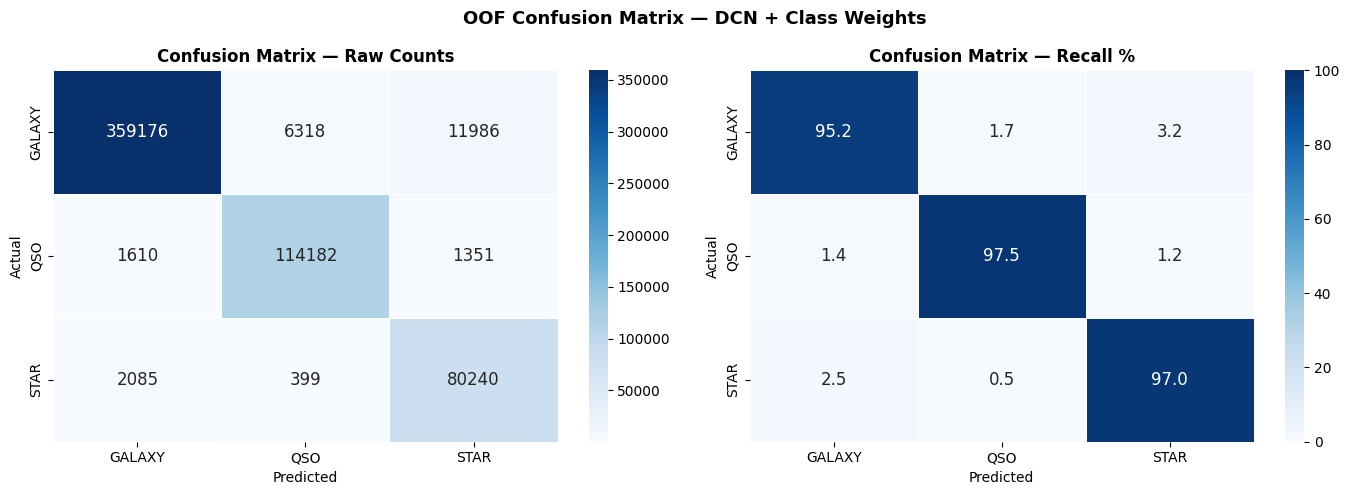

  GALAXY  : 95.15%  (359,176 / 377,480)
  QSO     : 97.47%  (114,182 / 117,143)
  STAR    : 97.00%  (80,240 / 82,724)


In [15]:
y_kag     = y_eval
probs_kag = oof_dcn * global_w
probs_kag = probs_kag / probs_kag.sum(axis=1, keepdims=True)
preds_kag = probs_kag.argmax(axis=1)
train_kag = train_augmented.iloc[kag_idx].reset_index(drop=True)

cm     = confusion_matrix(y_kag, preds_kag)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

print(f'OOF Balanced Accuracy: {global_score:.5f}')
print(f'CV  : {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}')
print()
print(classification_report(y_kag, preds_kag, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.5, annot_kws={'size': 12})
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=100,
            annot_kws={'size': 12})
axes[1].set_title('Confusion Matrix — Recall %', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.suptitle('OOF Confusion Matrix — DCN + Class Weights',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

for i, cls in enumerate(le.classes_):
    print(f'  {cls:8s}: {cm_pct[i,i]:.2f}%  ({cm[i,i]:,} / {cm[i].sum():,})')

## Calibration

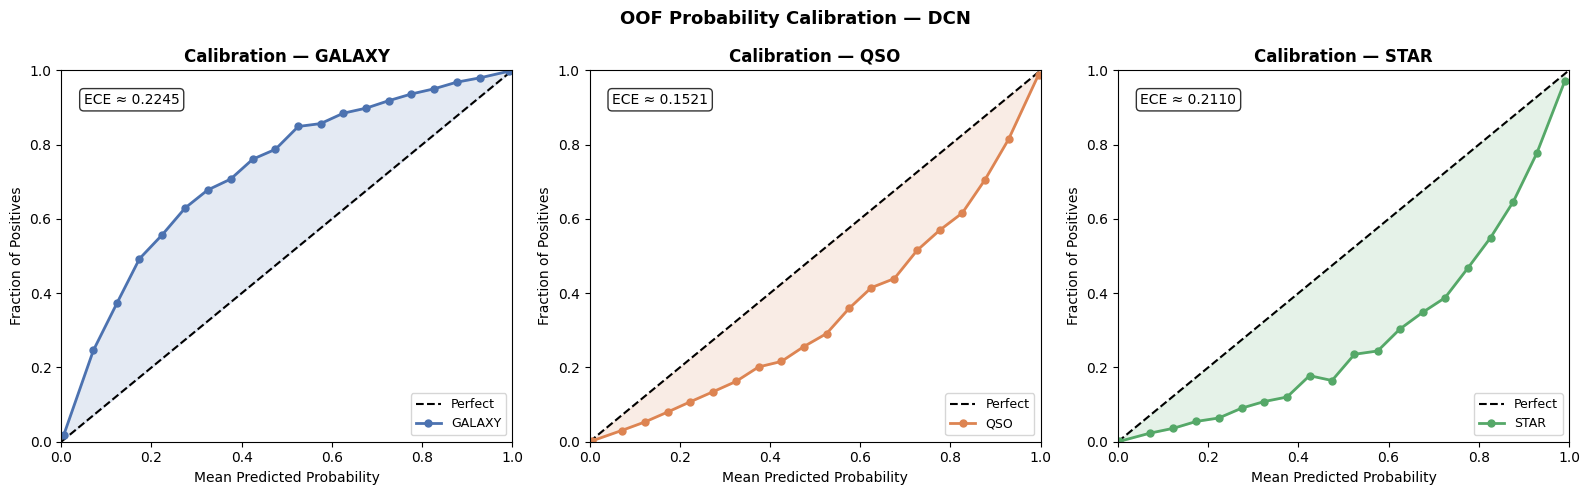

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for cls_idx, cls_name in enumerate(le.classes_):
    ax     = axes[cls_idx]
    y_bin  = (y_kag == cls_idx).astype(int)
    y_prob = probs_kag[:, cls_idx]
    prob_true, prob_pred = calibration_curve(y_bin, y_prob, n_bins=20)
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect')
    ax.plot(prob_pred, prob_true, 'o-',
            color=CLASS_COLORS[cls_name], lw=2, ms=5, label=cls_name)
    ax.fill_between(prob_pred, prob_true, prob_pred,
                    alpha=0.15, color=CLASS_COLORS[cls_name])
    ece = np.mean(np.abs(prob_true - prob_pred))
    ax.text(0.05, 0.91, f'ECE ≈ {ece:.4f}', transform=ax.transAxes,
            fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'Calibration — {cls_name}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle('OOF Probability Calibration — DCN', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Error Analysis

Total errors  : 23,749  (4.11%)
Total correct : 553,598 (95.89%)

Error breakdown by TRUE class:
        n_errors  avg_confidence  median_redshift  pct_of_class
y_true                                                         
GALAXY     18304           0.767            0.134         4.849
QSO         2961           0.783            0.292         2.528
STAR        2484           0.742            0.110         3.003

Top confusion pairs (true → predicted):
               count  avg_confidence  median_redshift  median_gr
y_true y_pred                                                   
GALAXY STAR    11986        0.761206         0.076018   0.832846
       QSO      6318        0.777349         0.939613   0.361917
STAR   GALAXY   2085        0.755485         0.103863   1.190448
QSO    GALAXY   1610        0.790641         0.795437   0.758836
       STAR     1351        0.774582         0.086086   0.270284
STAR   QSO       399        0.670878         0.158559   0.232614


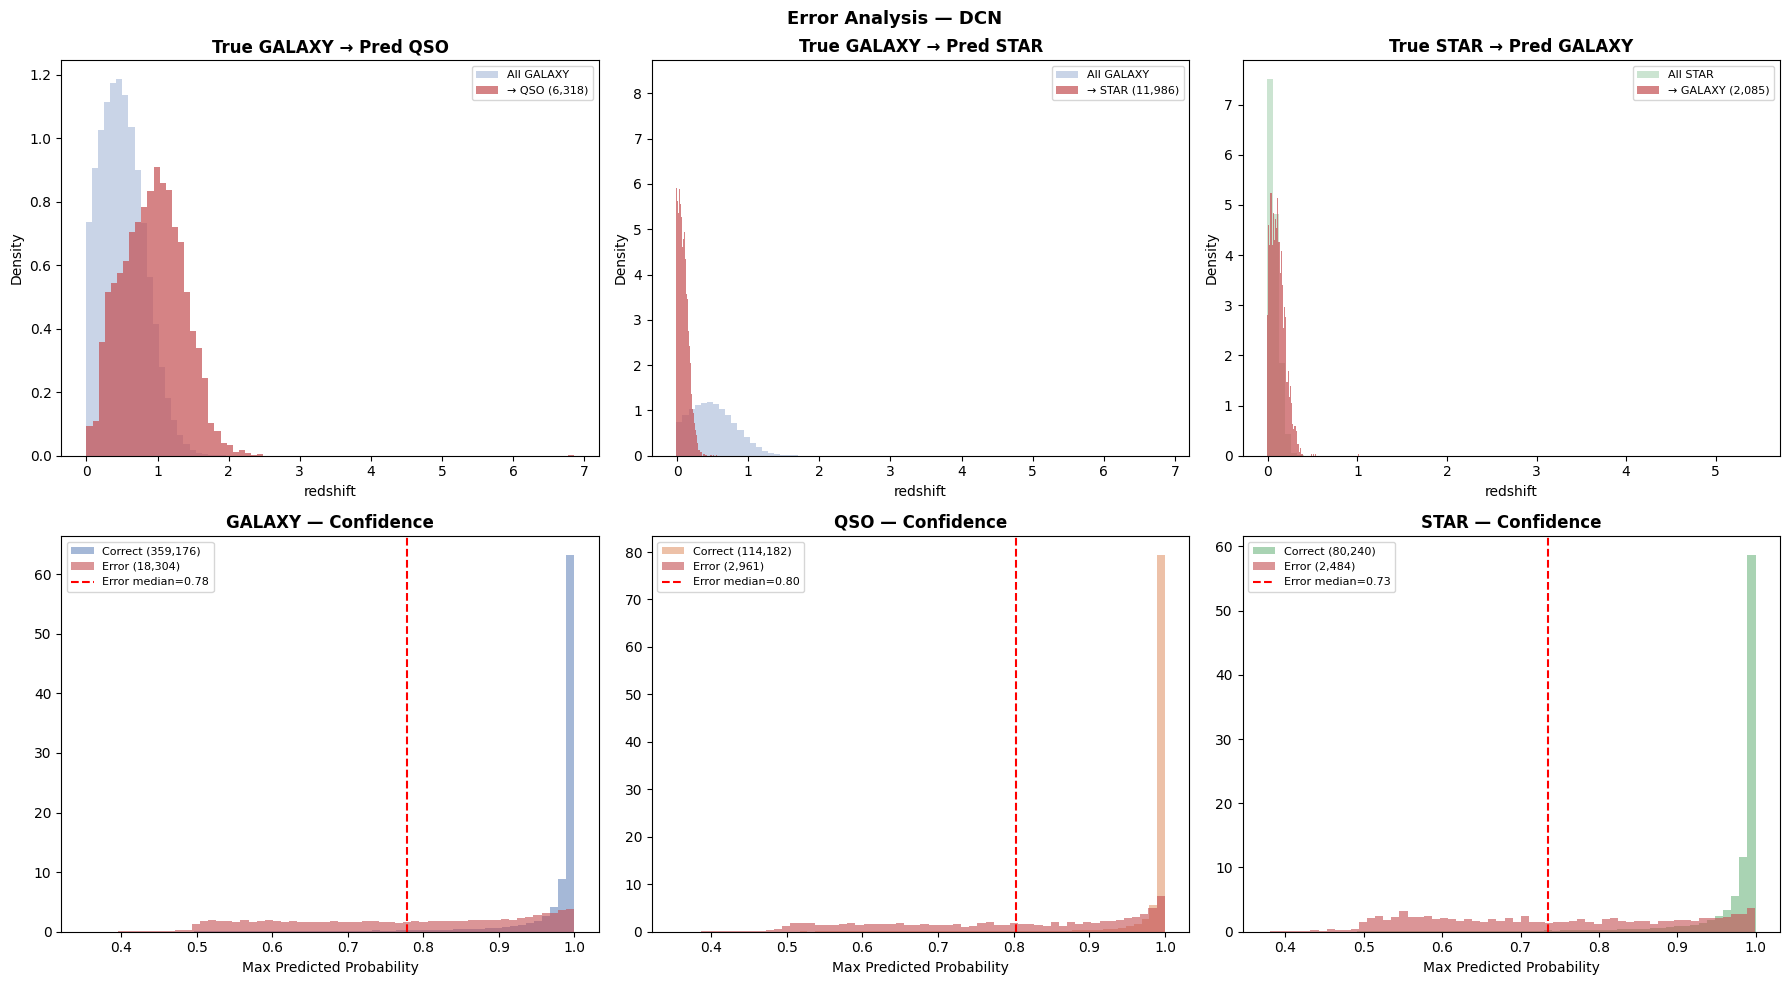

In [17]:
error_df = train_kag[['redshift', 'g_r', 'u_g', 'spectral_type',
                       'galaxy_population', 'class']].copy()
error_df['y_true']   = le.inverse_transform(y_kag)
error_df['y_pred']   = le.inverse_transform(preds_kag)
error_df['correct']  = (error_df['y_true'] == error_df['y_pred'])
error_df['max_prob'] = probs_kag.max(axis=1)

errors  = error_df[~error_df['correct']].copy()
correct = error_df[ error_df['correct']].copy()

print(f'Total errors  : {len(errors):,}  ({len(errors)/len(train_kag)*100:.2f}%)')
print(f'Total correct : {len(correct):,} ({len(correct)/len(train_kag)*100:.2f}%)')

print('\nError breakdown by TRUE class:')
err_by_true = errors.groupby('y_true').agg(
    n_errors=('correct', 'count'),
    avg_confidence=('max_prob', 'mean'),
    median_redshift=('redshift', 'median'),
)
err_by_true['pct_of_class'] = [
    len(errors[errors['y_true'] == c]) /
    len(train_kag[train_kag['class'] == c]) * 100
    for c in err_by_true.index
]
print(err_by_true.round(3).to_string())

print('\nTop confusion pairs (true → predicted):')
print(
    errors.groupby(['y_true', 'y_pred'])
    .agg(count=('correct','count'),
         avg_confidence=('max_prob','mean'),
         median_redshift=('redshift','median'),
         median_gr=('g_r','median'))
    .sort_values('count', ascending=False)
    .to_string()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (tc, pc) in zip(axes[0],
        [('GALAXY','QSO'), ('GALAXY','STAR'), ('STAR','GALAXY')]):
    mask    = (errors['y_true'] == tc) & (errors['y_pred'] == pc)
    err_sub = errors[mask]
    ax.hist(train_kag[train_kag['class']==tc]['redshift'], bins=80, alpha=0.3,
            color=CLASS_COLORS[tc], density=True, label=f'All {tc}')
    ax.hist(err_sub['redshift'], bins=80, alpha=0.7,
            color='#C44E52', density=True, label=f'→ {pc} ({len(err_sub):,})')
    ax.set_title(f'True {tc} → Pred {pc}', fontweight='bold')
    ax.set_xlabel('redshift'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

for ax, cls in zip(axes[1], CLASS_ORDER):
    mask     = error_df['y_true'] == cls
    err_conf = error_df.loc[mask & ~error_df['correct'], 'max_prob']
    ok_conf  = error_df.loc[mask &  error_df['correct'], 'max_prob']
    ax.hist(ok_conf,  bins=60, alpha=0.5, color=CLASS_COLORS[cls],
            density=True, label=f'Correct ({len(ok_conf):,})')
    ax.hist(err_conf, bins=60, alpha=0.6, color='#C44E52',
            density=True, label=f'Error ({len(err_conf):,})')
    ax.axvline(err_conf.median(), color='red', linestyle='--', lw=1.5,
               label=f'Error median={err_conf.median():.2f}')
    ax.set_title(f'{cls} — Confidence', fontweight='bold')
    ax.set_xlabel('Max Predicted Probability')
    ax.legend(fontsize=8)

plt.suptitle('Error Analysis — DCN',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Submission

Saved: submission.csv
GALAXY    155753
QSO        51732
STAR       39950
Low-confidence (<60%): 4,669 (1.89%)


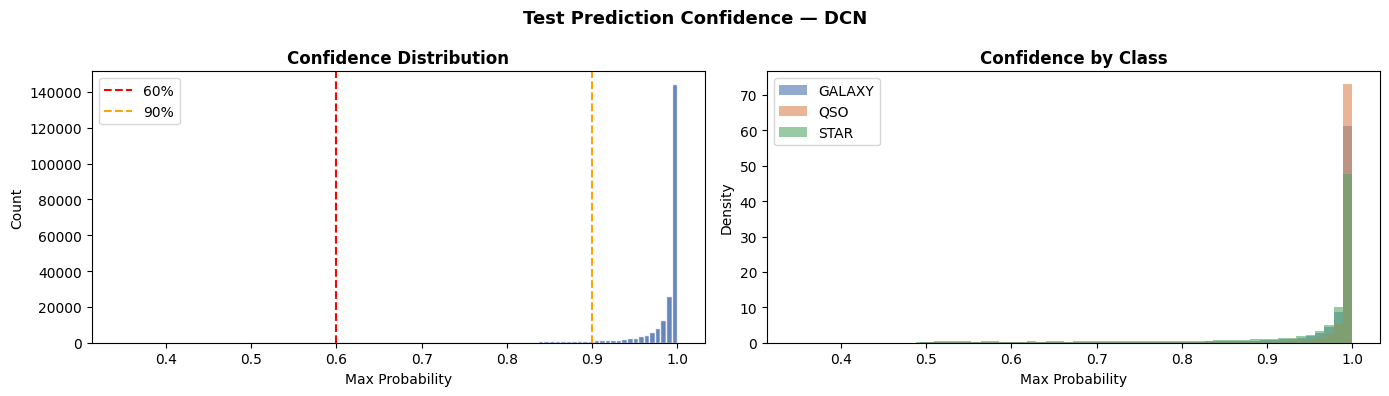


OOF Balanced Accuracy : 0.96538
CV  Balanced Accuracy : 0.96538 ± 0.00051
OOF BA with weights   : 0.96540


In [18]:
labels = le.inverse_transform(test_final.argmax(axis=1))

sub = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv')
sub['class'] = labels
sub.to_csv('submission.csv', index=False)

low_conf = (test_final.max(axis=1) < 0.6).sum()
print(f'Saved: submission.csv')
print(pd.Series(labels).value_counts().to_string())
print(f'Low-confidence (<60%): {low_conf:,} ({low_conf/len(labels)*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(test_final.max(axis=1), bins=100,
             color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(0.6, color='red',    linestyle='--', label='60%')
axes[0].axvline(0.9, color='orange', linestyle='--', label='90%')
axes[0].set_xlabel('Max Probability'); axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution', fontweight='bold')
axes[0].legend()

for idx, cls_name in enumerate(le.classes_):
    mask = test_final.argmax(axis=1) == idx
    axes[1].hist(test_final[mask].max(axis=1), bins=60, alpha=0.6,
                 color=CLASS_COLORS[cls_name], density=True, label=cls_name)
axes[1].set_xlabel('Max Probability'); axes[1].set_ylabel('Density')
axes[1].set_title('Confidence by Class', fontweight='bold')
axes[1].legend()
plt.suptitle('Test Prediction Confidence — DCN', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nOOF Balanced Accuracy : {oof_score:.5f}')
print(f'CV  Balanced Accuracy : {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}')
print(f'OOF BA with weights   : {global_score:.5f}')